In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/hepatitisC (1).csv")

In [ ]:
df.head()


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [ ]:
df.shape


(615, 14)

In [ ]:
df.columns


Index(['Unnamed: 0', 'Category', 'Age', 'Sex', 'ALB', 'ALP', 'ALT', 'AST',
       'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT'],
      dtype='object')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB


In [ ]:
df['Category'].value_counts()


,count
Category,
0=Blood Donor,533
3=Cirrhosis,30
1=Hepatitis,24
2=Fibrosis,21
0s=suspect Blood Donor,7


In [ ]:
df_clean = df[df['Category'] != '0s=suspect Blood Donor']

In [ ]:
df_clean['Category'].value_counts()


,count
Category,
0=Blood Donor,533
3=Cirrhosis,30
1=Hepatitis,24
2=Fibrosis,21


In [ ]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 608 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  608 non-null    int64  
 1   Category    608 non-null    object 
 2   Age         608 non-null    int64  
 3   Sex         608 non-null    object 
 4   ALB         607 non-null    float64
 5   ALP         590 non-null    float64
 6   ALT         607 non-null    float64
 7   AST         608 non-null    float64
 8   BIL         608 non-null    float64
 9   CHE         608 non-null    float64
 10  CHOL        598 non-null    float64
 11  CREA        608 non-null    float64
 12  GGT         608 non-null    float64
 13  PROT        607 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 71.2+ KB


In [ ]:
df_clean.isnull().sum()


,0
Unnamed: 0,0
Category,0
Age,0
Sex,0
ALB,1
ALP,18
ALT,1
AST,0
BIL,0
CHE,0


In [ ]:
#elimino unnamed porque es una variable que arrastro el csv por error

In [ ]:
#valores nulos muy pocos (<3%)

In [ ]:
df_clean = df_clean.drop(columns=['Unnamed: 0'])


In [ ]:
df_clean.head()


,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [ ]:
#imputamos valores perdidos , Limpieza de datos reemplazamos los valores perdidos por la mediana.


In [ ]:
for col in ['ALB', 'ALP', 'ALT', 'CHOL', 'PROT']:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

In [ ]:
df_clean.isnull().sum()


,0
Category,0
Age,0
Sex,0
ALB,0
ALP,0
ALT,0
AST,0
BIL,0
CHE,0
CHOL,0


In [ ]:
# convertir texto en números : variables sex y category las pasamos a numeros para que el ML lo entienda

In [ ]:
#vemos que valores hay en cada variable
df_clean['Sex'].unique()


array(['m', 'f'], dtype=object)

In [ ]:
#reemplazamos la m con 0 y la f con 1
df_clean['Sex'] = df_clean['Sex'].map({'m': 0, 'f': 1})


In [ ]:
#seguimos con categorias
#0 = sano 1 = hepatitis 2 = fibrosis 3 = cirrosis

df_clean['Category'] = df_clean['Category'].str.extract(r'(\d)').astype(int)

In [ ]:
df_clean.head()


,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0,32,0,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0,32,0,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0,32,0,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0,32,0,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0,32,0,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [ ]:
df_clean.dtypes


,0
Category,int64
Age,int64
Sex,int64
ALB,float64
ALP,float64
ALT,float64
AST,float64
BIL,float64
CHE,float64
CHOL,float64


In [ ]:
#Exploratory Data Analysis (EDA), Distribución de clases

In [ ]:
df_clean['Category'].value_counts()


,count
Category,
0,533
3,30
1,24
2,21


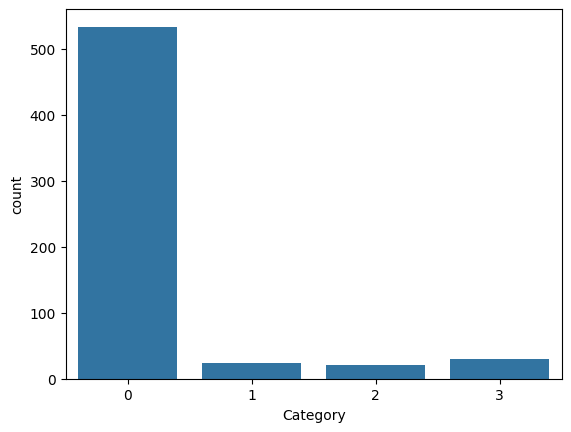

In [ ]:
sns.countplot(x='Category', data=df_clean)
plt.show()


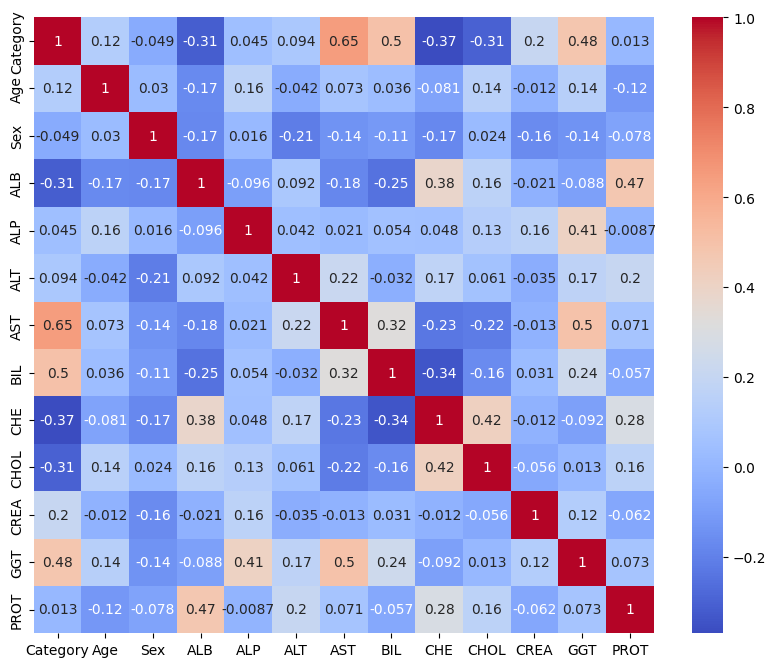

In [ ]:
# correlaciones entre variables: que variables se relacionan, posibles redundancias y patrones clínicos

plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.show()


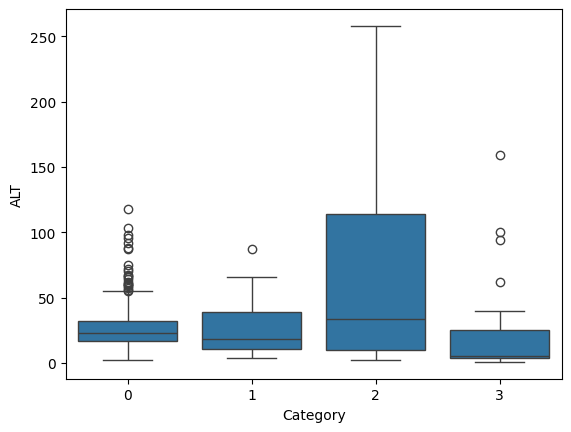

In [ ]:
#Distribución de variables clave, por ejemplo con ALT

sns.boxplot(x='Category', y='ALT', data=df_clean)
plt.show()


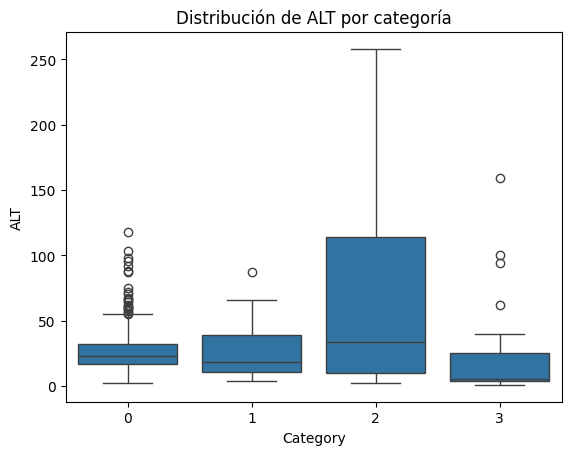

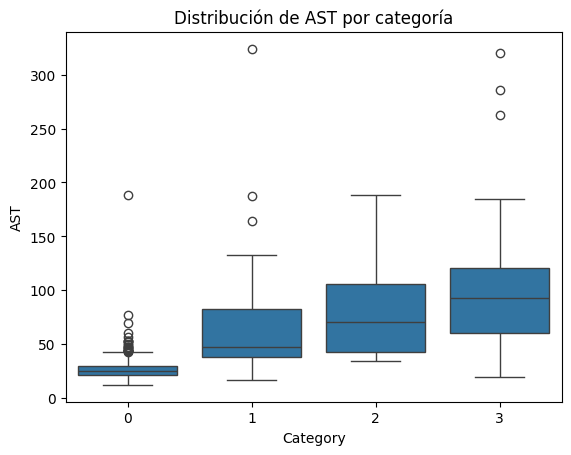

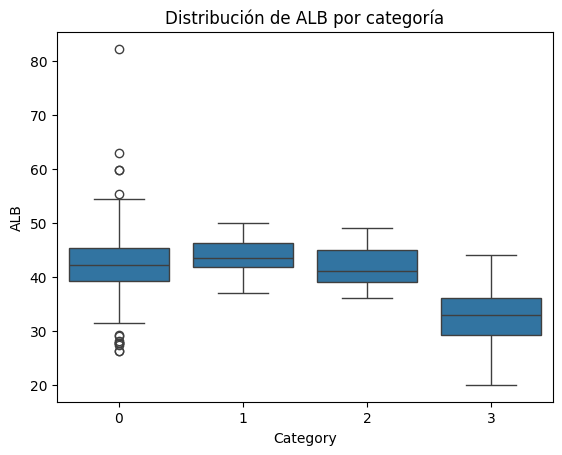

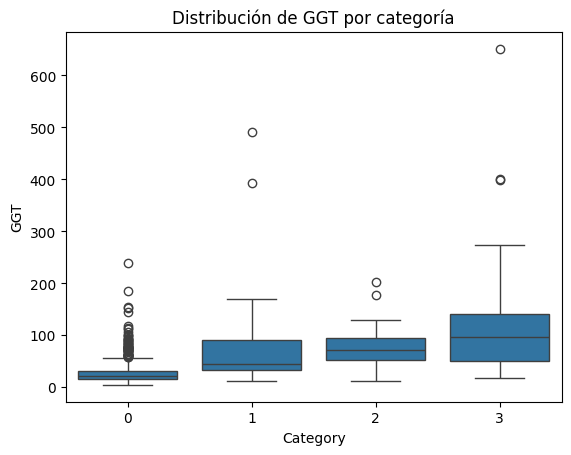

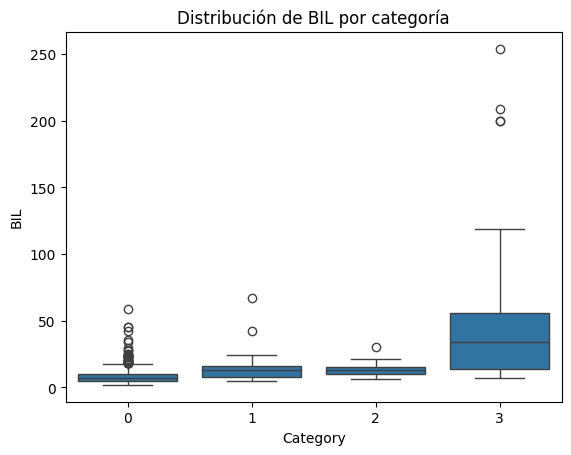

In [ ]:
variables = ['ALT', 'AST', 'ALB', 'GGT', 'BIL']

for var in variables:
    sns.boxplot(x='Category', y=var, data=df_clean)
    plt.title(f'Distribución de {var} por categoría')
    plt.show()


In [ ]:
# estadística descriptiva por categoría
estadisticas = df_clean.groupby('Category')[['ALT', 'AST', 'ALB', 'ALP', 'GGT', 'BIL', 'CHOL', 'CHE', 'CREA', 'PROT']].agg(['mean', 'std', 'min', 'max']).round(2)
print(estadisticas)

            ALT                        AST                        ALB        \
           mean    std  min    max    mean    std   min    max   mean   std   
Category                                                                      
0         26.63  14.50  2.5  118.1   26.55  10.62  12.0  188.7  42.24  5.03   
1         26.74  22.11  3.8   87.0   75.73  68.78  16.7  324.0  43.83  3.51   
2         59.60  66.70  2.4  258.0   81.17  42.26  34.0  187.9  41.76  3.74   
3         22.97  36.36  0.9  159.0  107.46  74.64  19.2  319.8  32.80  5.97   

          ...   CHE           CREA                         PROT              \
          ...   min    max    mean     std   min     max   mean   std   min   
Category  ...                                                                 
0         ...  3.90  15.43   78.98   14.51   8.0   127.0  72.11  4.55  51.0   
1         ...  5.75  16.41   73.96   19.77  45.4   147.3  74.70  6.08  63.0   
2         ...  3.99  11.49   73.49   12.92  55.2   

In [ ]:
#empezamos ML

X = df_clean.drop('Category', axis=1)
y = df_clean['Category']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# regresion logistica

from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=500)

model_lr.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=500)

In [ ]:
y_pred_lr = model_lr.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       1.00      0.20      0.33         5
           2       1.00      0.75      0.86         4
           3       0.83      0.83      0.83         6

    accuracy                           0.95       122
   macro avg       0.95      0.70      0.75       122
weighted avg       0.95      0.95      0.94       122

[[107   0   0   0]
 [  3   1   0   1]
 [  1   0   3   0]
 [  1   0   0   5]]


In [ ]:
# random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)


In [ ]:
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       0.50      0.20      0.29         5
           2       0.50      0.25      0.33         4
           3       0.83      0.83      0.83         6

    accuracy                           0.93       122
   macro avg       0.70      0.57      0.61       122
weighted avg       0.92      0.93      0.92       122

[[107   0   0   0]
 [  2   1   1   1]
 [  2   1   1   0]
 [  1   0   0   5]]


In [ ]:
# aplico class_weight en regresión logística

model_lr_balanced = LogisticRegression(
    max_iter=500,
    class_weight='balanced'
)

model_lr_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_lr_balanced.predict(X_test_scaled)

print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))


              precision    recall  f1-score   support

           0       1.00      0.96      0.98       107
           1       0.50      0.80      0.62         5
           2       0.75      0.75      0.75         4
           3       0.71      0.83      0.77         6

    accuracy                           0.94       122
   macro avg       0.74      0.84      0.78       122
weighted avg       0.96      0.94      0.95       122

[[103   3   0   1]
 [  0   4   0   1]
 [  0   1   3   0]
 [  0   0   1   5]]


In [ ]:
#ahora interpretamos el modelo ¿qué variables impactan mas?

In [ ]:
import pandas as pd

coef = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model_lr_balanced.coef_[0]
})

coef.sort_values(by='Coeficiente', ascending=False)


,Variable,Coeficiente
3,ALP,1.386012
8,CHOL,0.489251
2,ALB,0.394725
4,ALT,0.229047
0,Age,0.084641
7,CHE,-0.045440
9,CREA,-0.271946
1,Sex,-0.332046
11,PROT,-0.476933
6,BIL,-0.741416


In [ ]:
from scipy.stats import kruskal

# las variables que voy a analizar:

variables = ['ALT', 'AST', 'ALB']

print(" CONTRASTES DE HIPÓTESIS (Kruskal-Wallis) \n")

for var in variables:
    groups = [df_clean[df_clean['Category'] == i][var] for i in sorted(df_clean['Category'].unique())]

    stat, p = kruskal(*groups)

    print(f"Variable: {var}")
    print(f"Estadístico: {stat:.3f}")
    print(f"p-valor: {p:.5f}")

    if p < 0.05:
        print("→ Diferencias significativas entre grupos\n")
    else:
        print("→ No hay diferencias significativas\n")

 CONTRASTES DE HIPÓTESIS (Kruskal-Wallis) 

Variable: ALT
Estadístico: 21.860
p-valor: 0.00007
→ Diferencias significativas entre grupos

Variable: AST
Estadístico: 158.142
p-valor: 0.00000
→ Diferencias significativas entre grupos

Variable: ALB
Estadístico: 58.076
p-valor: 0.00000
→ Diferencias significativas entre grupos

